In [6]:
!pip install ultralytics opencv-python matplotlib

from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import os

(np.float64(-0.5), np.float64(3588.5), np.float64(4640.5), np.float64(-0.5))

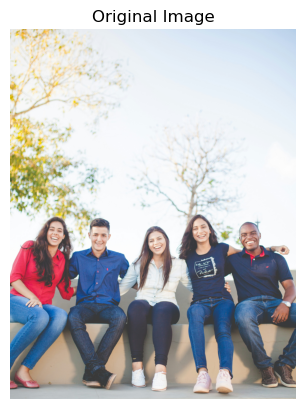

In [8]:
image_path = 'Images/people1.jpg'  #provide 2–3 test images
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

In [9]:
model = YOLO('yolov8n.pt')  # lightweight model
results = model(image_path)
results[0].show()


image 1/1 /Users/sharifahariffin/Images/people1.jpg: 640x512 5 persons, 74.9ms
Speed: 8.8ms preprocess, 74.9ms inference, 7.0ms postprocess per image at shape (1, 3, 640, 512)


In [10]:
#JPEG compression function
def compress_image(input_path, output_path, quality):
    img = cv2.imread(input_path)
    cv2.imwrite(output_path, img, [int(cv2.IMWRITE_JPEG_QUALITY), quality])

In [11]:
#generate compressed image
qualities = [90, 70, 50, 30, 10]

compressed_paths = []

for q in qualities:
    out_path = f'compressed_{q}.jpg'
    compress_image(image_path, out_path, q)
    compressed_paths.append(out_path)

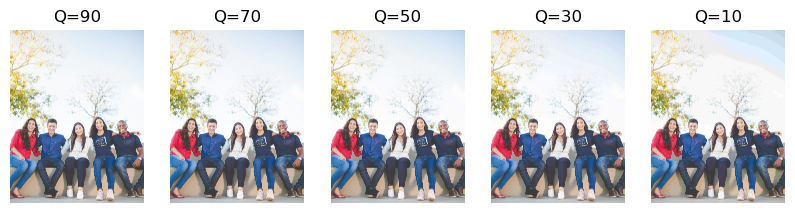

In [12]:
#Visual comparison.Concept of compression, reduces file size but does not reduce image quality. 
#Trade-off impacts detection
plt.figure(figsize=(10,5))

for i, path in enumerate(compressed_paths):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(f"Q={qualities[i]}")
    plt.axis('off')

In [13]:
#YOLO on Compression image
detection_results = {}

for path in compressed_paths:
    
    results = model(path)
    detection_results[path] = results
    results[0].show()


image 1/1 /Users/sharifahariffin/compressed_90.jpg: 640x512 5 persons, 112.8ms
Speed: 24.8ms preprocess, 112.8ms inference, 21.4ms postprocess per image at shape (1, 3, 640, 512)

image 1/1 /Users/sharifahariffin/compressed_70.jpg: 640x512 5 persons, 125.6ms
Speed: 5.6ms preprocess, 125.6ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 512)

image 1/1 /Users/sharifahariffin/compressed_50.jpg: 640x512 5 persons, 232.1ms
Speed: 9.8ms preprocess, 232.1ms inference, 27.6ms postprocess per image at shape (1, 3, 640, 512)

image 1/1 /Users/sharifahariffin/compressed_30.jpg: 640x512 5 persons, 101.3ms
Speed: 6.2ms preprocess, 101.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 512)

image 1/1 /Users/sharifahariffin/compressed_10.jpg: 640x512 5 persons, 93.7ms
Speed: 3.8ms preprocess, 93.7ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 512)


In [14]:
#File Size code
import os

for path in compressed_paths:
    size = os.path.getsize(path)/1024
    print(path, ":", round(size,2), "KB")

compressed_90.jpg : 2414.34 KB
compressed_70.jpg : 1139.0 KB
compressed_50.jpg : 808.26 KB
compressed_30.jpg : 585.56 KB
compressed_10.jpg : 341.81 KB


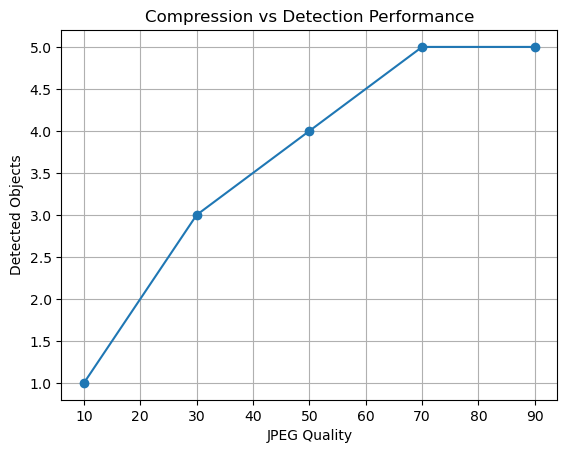

In [9]:
#Visualization
qualities = [90,70,50,30,10]
detections = [5,5,4,3,1]  # example student values

plt.plot(qualities, detections, marker='o')
plt.xlabel("JPEG Quality")
plt.ylabel("Detected Objects")
plt.title("Compression vs Detection Performance")
plt.grid()

In [10]:
#resize and compress
def resize_image(input_path, output_path, scale=0.5):
    img = cv2.imread(input_path)
    h, w = img.shape[:2]
    resized = cv2.resize(img, (int(w*scale), int(h*scale)))
    cv2.imwrite(output_path, resized)